In [28]:
#1. IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [29]:
#2. IMPORTING THE DATASET
df=pd.read_csv('weatherHistory.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  int64  
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  int64  
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(6), int64(2), object(4)
memory usage: 8.8+ MB


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251,15.8263,0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259,15.8263,0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204,14.9569,0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269,15.8263,0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259,15.8263,0,1016.51,Partly cloudy throughout the day.


In [30]:
df=df.drop(['Formatted Date','Precip Type','Loud Cover','Daily Summary'], axis=1)

In [33]:
#CREATE NEW FEATURES
df['temp_humidity_ratio'] = df['Temperature (C)'] / (df['Humidity'] + 1e-6)
df['wind_pressure_score'] = df['Wind Speed (km/h)'] * df['Pressure (millibars)']

In [34]:
X=df.drop('Apparent Temperature (C)',axis=1)
y=df['Apparent Temperature (C)']
print(df)
print(X)
print(y)

             Summary  Temperature (C)  Apparent Temperature (C)  Humidity  \
0      Partly Cloudy         9.472222                  7.388889      0.89   
1      Partly Cloudy         9.355556                  7.227778      0.86   
2      Mostly Cloudy         9.377778                  9.377778      0.89   
3      Partly Cloudy         8.288889                  5.944444      0.83   
4      Mostly Cloudy         8.755556                  6.977778      0.83   
...              ...              ...                       ...       ...   
96448  Partly Cloudy        26.016667                 26.016667      0.43   
96449  Partly Cloudy        24.583333                 24.583333      0.48   
96450  Partly Cloudy        22.038889                 22.038889      0.56   
96451  Partly Cloudy        21.522222                 21.522222      0.60   
96452  Partly Cloudy        20.438889                 20.438889      0.61   

       Wind Speed (km/h)  Wind Bearing (degrees)  Visibility (km)  \
0     

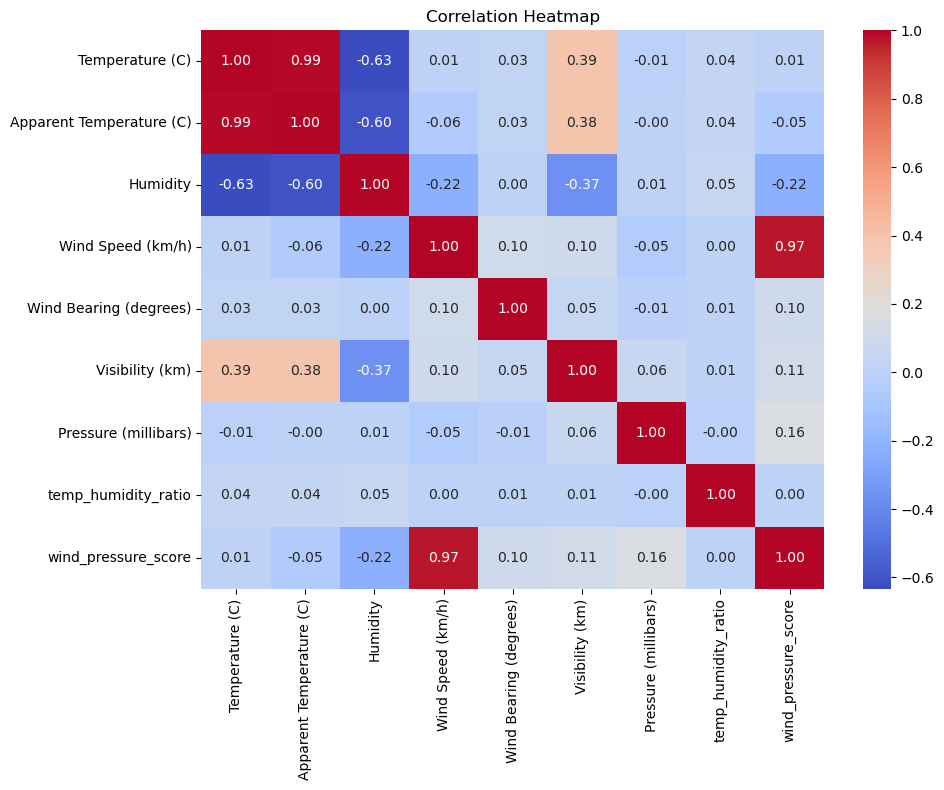

In [35]:
#VISUALISE THE DATASET IN HEATMAP
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop('Summary',axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

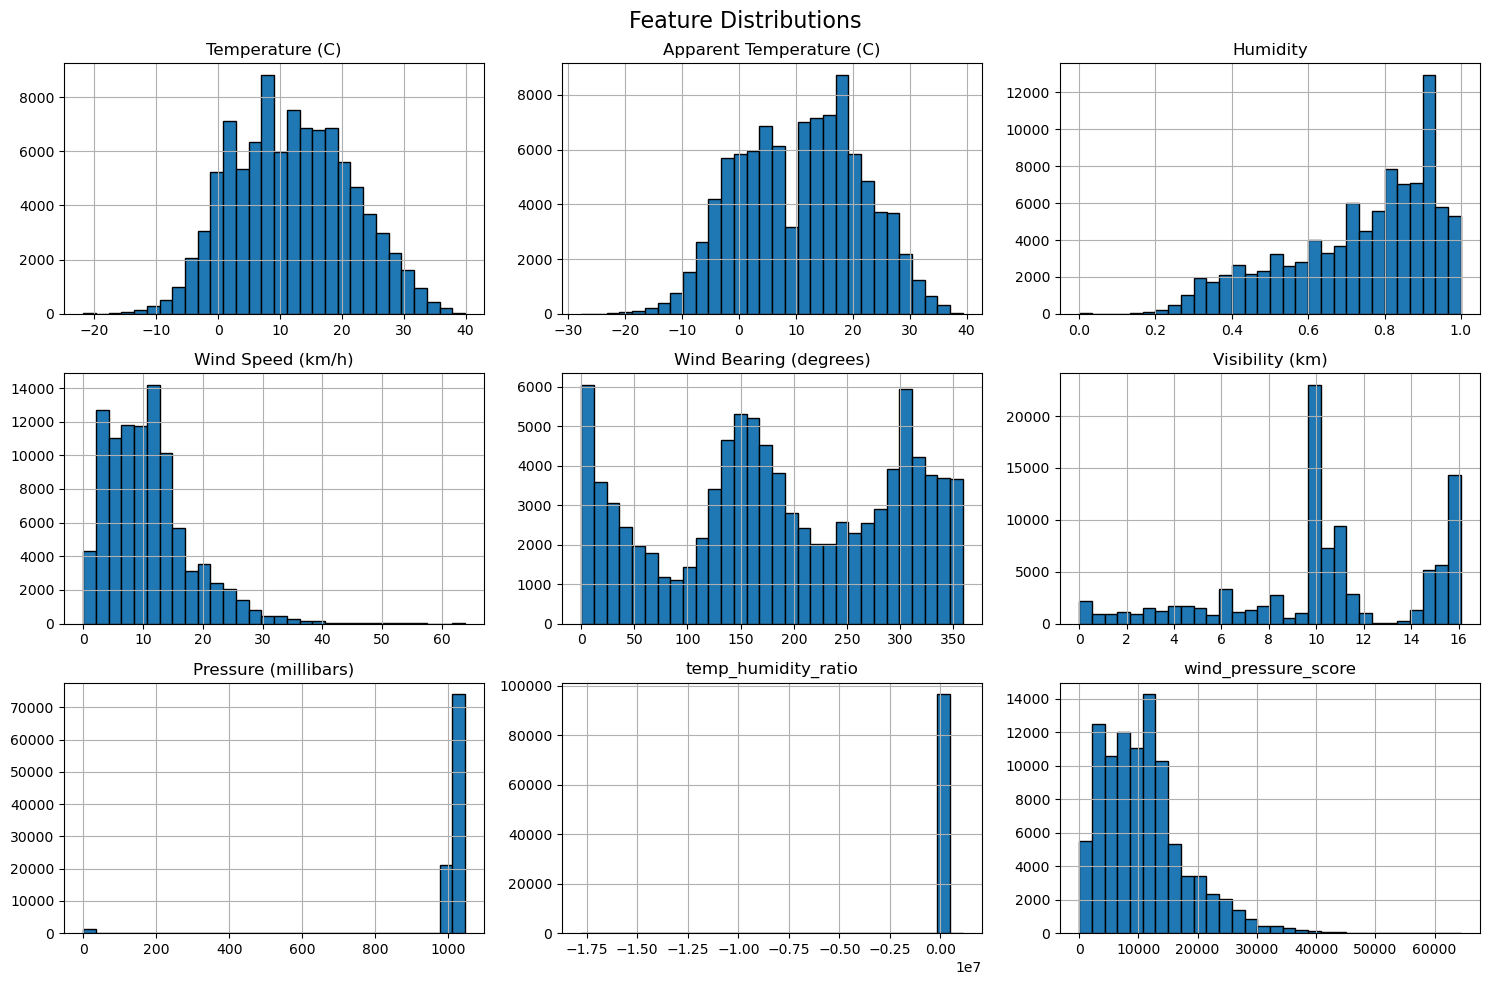

In [36]:
#VISUALIZE THE DATASET
df.hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

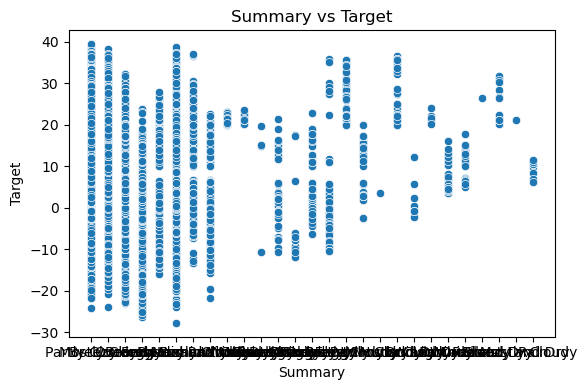

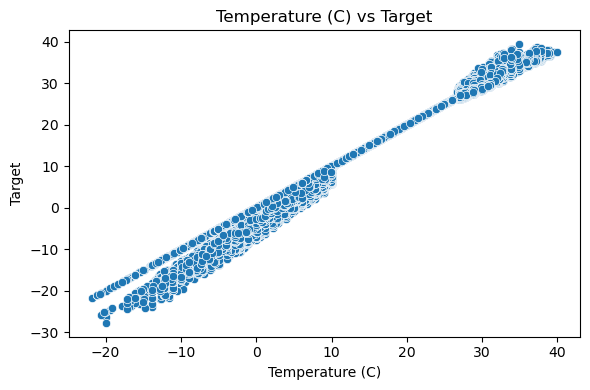

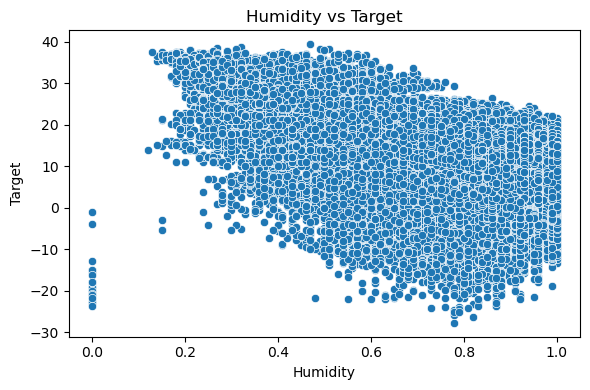

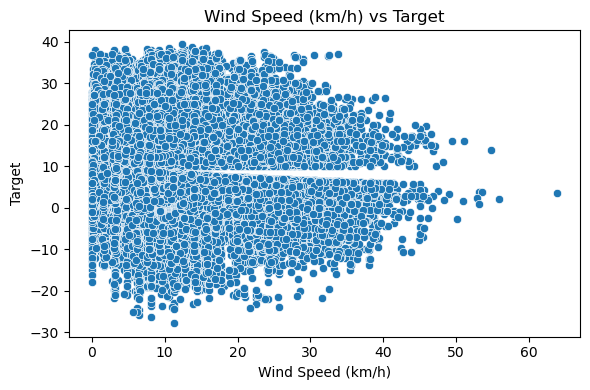

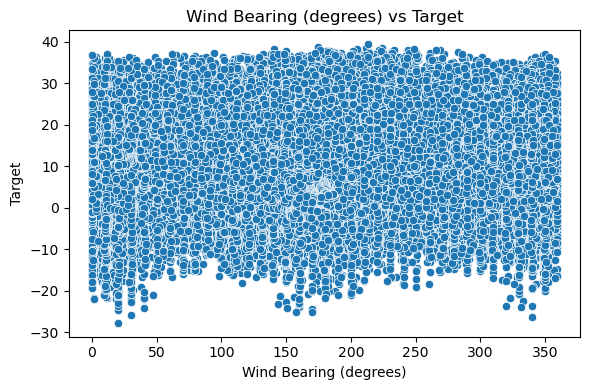

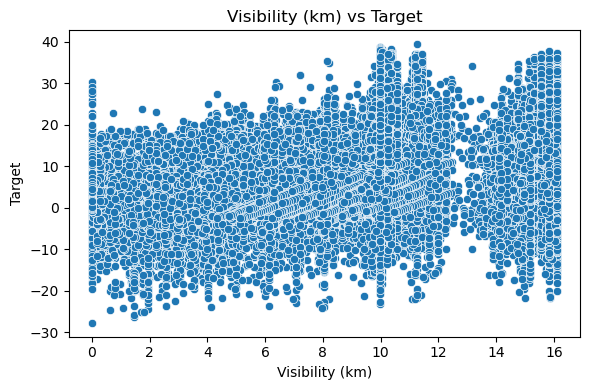

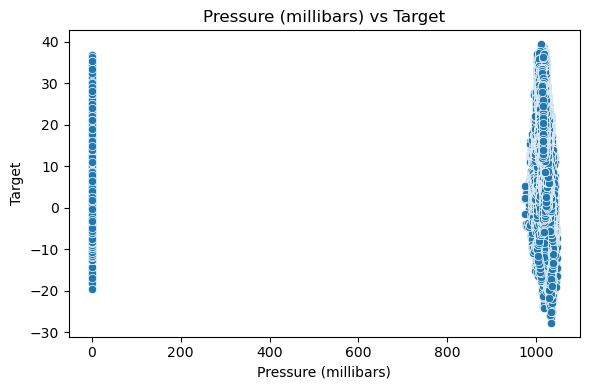

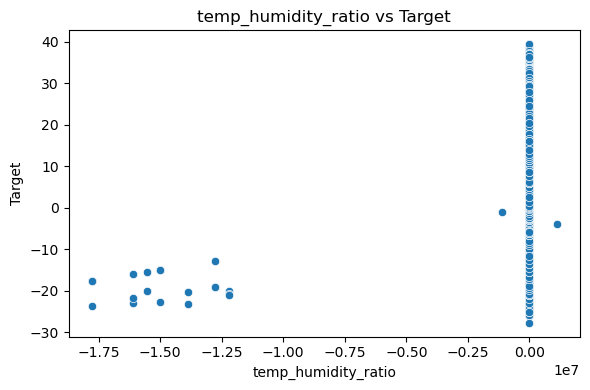

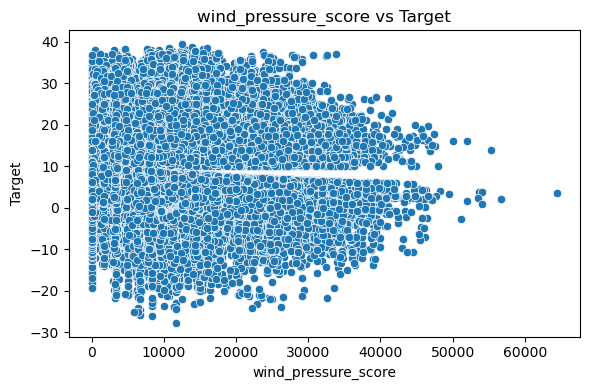

In [61]:
#VISUALIZE: FEATURE VS TARGET

for col in df.columns: 
    if col=='Apparent Temperature (C)':
        continue
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[col], y=df['Apparent Temperature (C)'])
    plt.title(f"{col} vs Target")
    plt.xlabel(col)
    plt.ylabel("Target")
    plt.tight_layout()
    plt.show()


In [38]:
#3. TAKING CARE OF MISSING VALUES
print(df.isnull().sum())

Summary                     0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Pressure (millibars)        0
temp_humidity_ratio         0
wind_pressure_score         0
dtype: int64


In [39]:
#4. ENCODING CATEGORICAL DATA
from sklearn.preprocessing import OneHotEncoder
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(sparse_output=False, handle_unknown='ignore'),[0])], 
                     remainder='passthrough')
X=np.array(ct.fit_transform(X))
print(X)

[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.01513000e+03
  1.06429344e+01 1.43333311e+04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.01563000e+03
  1.08785403e+01 1.44875557e+04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.01594000e+03
  1.05368171e+01 3.99101870e+03]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.01566000e+03
  3.93550885e+01 9.12448631e+03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.01595000e+03
  3.58703106e+01 1.06973439e+04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.01616000e+03
  3.35063203e+01 5.97146424e+03]]


In [53]:
#5. SPLITTING OF DATASET
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train)
print(X_test)
print(X_train.shape[0])
print(X_test.shape[0])

[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.01497000e+03
  1.60821592e+01 1.10301865e+04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.01007000e+03
  8.99666982e+00 3.38414863e+04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.01024000e+03
  1.88029589e+01 5.79029158e+03]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.01039000e+03
  1.15431956e+01 1.09966806e+04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.01244000e+03
  2.33671802e+01 7.82413632e+02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.01548000e+03
  5.55554938e+00 1.09866812e+04]]
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.01403000e+03
  5.30606965e+01 1.35341570e+04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.01790000e+03
  1.20481783e+01 1.47493710e+04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.02200000e+03
  2.21538121e+01 1.12875812e+04]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.01737000e+03
  2.02200876e+01 9.82779420e+03]

In [41]:
print(X_train.shape[1])

35


In [42]:
#6. FEATURE SCALING
sc=StandardScaler()
X_train[:,-9:]=sc.fit_transform(X_train[:,-9:])
X_test[:,-9:]=sc.transform(X_test[:,-9:])

In [55]:
#7. APPLYING DIMENSIONALITY REDUCTION- PCA
pca=PCA(n_components=9)
X_train=pca.fit_transform(X_train)
X_test=pca.transform(X_test)

In [62]:
#8. TRAINING THE MODEL ON THE DATASET AND PREDICTING THE TEST RESULTS 
model=LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [63]:
y_pred = model.predict(X_test)
print("R^2 Score:",r2_score(y_test, y_pred))
print("Mean Absolute Error:",mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:",mean_squared_error(y_test, y_pred))

R^2 Score: 0.9897866723831168
Mean Absolute Error: 0.8570787410449366
Mean Squared Error: 1.1816695788389064


In [45]:
print(RandomForestRegressor().get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [46]:
#8. TRAINING THE MODEL ON THE DATASET AND PREDICTING THE TEST RESULTS 
results = []
for n in range(100, 1000, 200):      
    for d in range(5, 11, 5):       
        print(f"Training with n_estimators={n}, max_depth={d}...")
        model = RandomForestRegressor(n_estimators=n, max_depth=d, n_jobs=-1, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        results.append((n, d, r2))
print(results)
best = max(results, key=lambda x: x[2])
print(f"\nBest configuration: n_estimators={best[0]}, max_depth={best[1]} with R^2 = {best[2]:.4f}")

Training with n_estimators=100, max_depth=5...
Training with n_estimators=100, max_depth=10...
Training with n_estimators=300, max_depth=5...
Training with n_estimators=300, max_depth=10...
Training with n_estimators=500, max_depth=5...
Training with n_estimators=500, max_depth=10...
Training with n_estimators=700, max_depth=5...
Training with n_estimators=700, max_depth=10...
Training with n_estimators=900, max_depth=5...
Training with n_estimators=900, max_depth=10...
[(100, 5, 0.8707609330471953), (100, 10, 0.9783664543816701), (300, 5, 0.869768361194251), (300, 10, 0.978395523025126), (500, 5, 0.8696915671660922), (500, 10, 0.9784035600345382), (700, 5, 0.8695911652781976), (700, 10, 0.978400638481514), (900, 5, 0.8697434082806195), (900, 10, 0.9784142980475398)]

Best configuration: n_estimators=900, max_depth=10 with R^2 = 0.9784


In [47]:
#9.TRYING HYPERPARAMETER TUNING USING GRIDSEARCHCV
from sklearn.model_selection import GridSearchCV

params = {'n_estimators': [100, 200], 'max_depth': [5, None],'n_jobs':[-1]}
grid = GridSearchCV(RandomForestRegressor(), params, cv=5)
grid.fit(X_train, y_train)
y_pred = grid.predict(X_test)
print("R^2 Score:",r2_score(y_test, y_pred))

R^2 Score: 0.9934051412488031


In [50]:
print("Mean Absolute Error:",mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:",mean_squared_error(y_test, y_pred))

Mean Absolute Error: 0.5717974386390046
Mean Squared Error: 0.7630171336271208


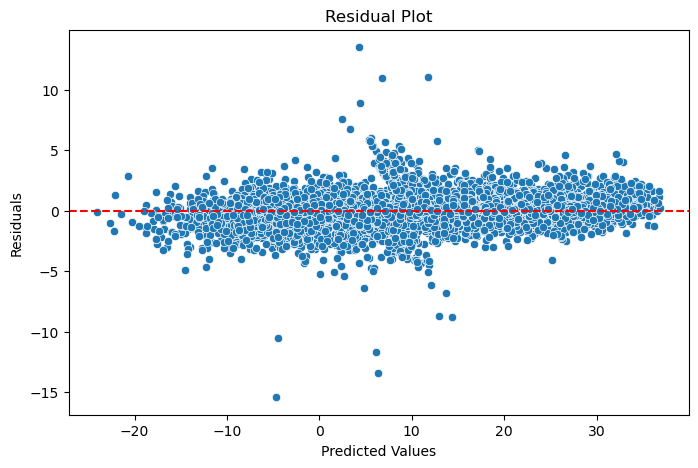

In [48]:
#VISUAIZE THE MODEL
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

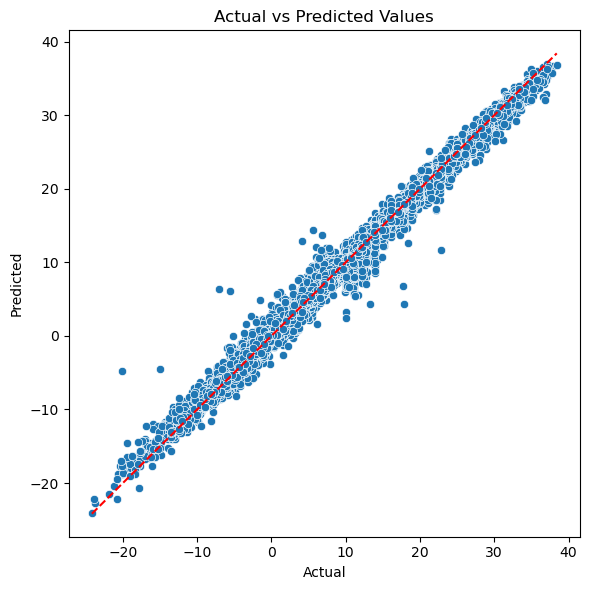

In [49]:
#VISUALIZE ACTUAL VS PREDICTED PLOT
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Values")
plt.tight_layout()
plt.show()